# Clustering
    - Author: Santiago Avella. Git hub: https://github.com/TiagoMimi

# Libraries

In [1]:
# ============================================================
# Data manipulation and numerical analysis
# ============================================================

import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical operations and array manipulation
from pathlib import Path     # Read the csv from the file path

# ============================================================
# Data visualization
# ============================================================

import seaborn as sns        # Statistical data visualization
import matplotlib.pyplot as plt  # General-purpose data visualization
import matplotlib.ticker as ticker  # Custom formatting for plot axes


pd.set_option('display.max_columns', None)

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load data

In [2]:
script_path = Path.cwd() 
csv_path = script_path.parent/"data"/"mall_medellin_V1.csv" 

df = pd.read_csv(csv_path,
                sep=";")

In [3]:
df

,year,quarter,customer_id,purchase_amount,business_establishment,gender,age_group,category,subcategory,day_week,month
0,2022,1Q,be189a4c9202d,50000,cine_colombia,M,18_32,entertainment,NO_FOOD,sun,1
1,2022,1Q,be189a4c9202d,100000,local_no_identificado,M,18_32,Unknown,NO_FOOD,sun,1
2,2022,1Q,5c2d817105231,100000,hatoviejo,M,59_71,restaurants_and_fast_food,RESTAURANTS,sun,1
3,2022,1Q,5f655501e54d3,270267,carulla,M,59_71,supermarket_and_pharmacy,NO_FOOD,sun,1
4,2022,1Q,5f655501e54d3,220485,caf_le_gris,M,59_71,restaurants_and_fast_food,RESTAURANTS,sun,1
...,...,...,...,...,...,...,...,...,...,...,...
443449,2024,2Q,eaf0f11aaf2d4,105532,carulla,F,46_58,supermarket_and_pharmacy,NO_FOOD,sun,6
443450,2024,2Q,eaf0f11aaf2d4,37649,pasteur,F,46_58,supermarket_and_pharmacy,NO_FOOD,sun,6
443451,2024,2Q,eaf0f11aaf2d4,227350,medipiel,F,46_58,beauty_and_cosmetic_centers,NO_FOOD,sun,6
443452,2024,2Q,6485ae245e887,245700,medipiel_2,F,33_45,supermarket_and_pharmacy,NO_FOOD,sun,6


# Transformation

## Delete columns not relevants

In [4]:
df = df.drop(columns=["quarter",
                    "subcategory"])

In [5]:
modes = (
    df.groupby("customer_id")[["gender", "age_group"]]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)

statistics = (
    df.groupby("customer_id")["purchase_amount"]
    .agg(
        average_purchase_value="mean"
    )
    .reset_index()
)

df_final = pd.merge(
    modes,
    statistics,
    on="customer_id",
    how="inner"
)

df_final

,customer_id,gender,age_group,average_purchase_value
0,00011c3fc00cc,F,46_58,78119.78
1,00015e5db3145,M,59_71,233280.00
2,000636cf3238e,F,33_45,252166.67
3,0007dfc4d8f0e,F,59_71,385500.00
4,0008b9d027a38,F,33_45,81054.50
...,...,...,...,...
50934,fffad23b80d52,F,18_32,48200.00
50935,fffb7e373540d,M,33_45,155911.00
50936,fffc4a0ab7734,F,59_71,94619.00
50937,fffdc71c8f256,F,46_58,143900.50


### Category

In [6]:
dummies_X = pd.get_dummies(df["category"], prefix="1", dtype=int)

df_dummies_category = pd.concat([df[["customer_id"]], dummies_X], axis=1)

df_dummies_category =df_dummies_category.groupby("customer_id").sum().reset_index()

df_dummies_category 


,customer_id,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency
0,00011c3fc00cc,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,12,0,0,3,0,0
1,00015e5db3145,0,0,0,3,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0
2,000636cf3238e,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0007dfc4d8f0e,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0008b9d027a38,0,0,0,0,0,0,0,2,0,0,0,0,0,5,0,0,0,0,0,0,0,0,11,0,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0
50935,fffb7e373540d,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
50936,fffc4a0ab7734,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
50937,fffdc71c8f256,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
df_final = pd.merge(df_final,
                    df_dummies_category,
                    on="customer_id",
                    how="inner")
df_final

,customer_id,gender,age_group,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency
0,00011c3fc00cc,F,46_58,78119.78,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,12,0,0,3,0,0
1,00015e5db3145,M,59_71,233280.00,0,0,0,3,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0
2,000636cf3238e,F,33_45,252166.67,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0007dfc4d8f0e,F,59_71,385500.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0008b9d027a38,F,33_45,81054.50,0,0,0,0,0,0,0,2,0,0,0,0,0,5,0,0,0,0,0,0,0,0,11,0,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,F,18_32,48200.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0
50935,fffb7e373540d,M,33_45,155911.00,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
50936,fffc4a0ab7734,F,59_71,94619.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
50937,fffdc71c8f256,F,46_58,143900.50,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Times Buy

In [8]:
df_times_buying = (df.groupby("customer_id").size().reset_index(name="times_buy"))
df_times_buying

,customer_id,times_buy
0,00011c3fc00cc,18
1,00015e5db3145,8
2,000636cf3238e,3
3,0007dfc4d8f0e,1
4,0008b9d027a38,20
...,...,...
50934,fffad23b80d52,3
50935,fffb7e373540d,2
50936,fffc4a0ab7734,1
50937,fffdc71c8f256,2


In [9]:
df_final = pd.merge(df_final,
                    df_times_buying,
                    on="customer_id",
                    how="inner")
df_final

,customer_id,gender,age_group,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency,times_buy
0,00011c3fc00cc,F,46_58,78119.78,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,12,0,0,3,0,0,18
1,00015e5db3145,M,59_71,233280.00,0,0,0,3,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,8
2,000636cf3238e,F,33_45,252166.67,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
3,0007dfc4d8f0e,F,59_71,385500.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0008b9d027a38,F,33_45,81054.50,0,0,0,0,0,0,0,2,0,0,0,0,0,5,0,0,0,0,0,0,0,0,11,0,0,2,0,0,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,F,18_32,48200.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3
50935,fffb7e373540d,M,33_45,155911.00,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50936,fffc4a0ab7734,F,59_71,94619.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
50937,fffdc71c8f256,F,46_58,143900.50,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2


### Day of the week

In [10]:
dummies_X = pd.get_dummies(df["day_week"], prefix="X", dtype=int)

df_dummies_dayweek = pd.concat([df[["customer_id"]], dummies_X], axis=1)

df_dummies_dayweek =df_dummies_dayweek.groupby("customer_id").sum().reset_index()

In [11]:
df_final = pd.merge(df_final,
                    df_dummies_dayweek,
                    on="customer_id",
                    how="inner")
df_final

,customer_id,gender,age_group,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency,times_buy,X_fri,X_mon,X_sat,X_sun,X_thu,X_tue,X_wed
0,00011c3fc00cc,F,46_58,78119.78,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,12,0,0,3,0,0,18,1,3,0,9,2,3,0
1,00015e5db3145,M,59_71,233280.00,0,0,0,3,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,8,5,0,1,1,0,0,1
2,000636cf3238e,F,33_45,252166.67,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,2,0
3,0007dfc4d8f0e,F,59_71,385500.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,0008b9d027a38,F,33_45,81054.50,0,0,0,0,0,0,0,2,0,0,0,0,0,5,0,0,0,0,0,0,0,0,11,0,0,2,0,0,20,0,5,3,8,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,F,18_32,48200.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3,0,0,0,0,0,3,0
50935,fffb7e373540d,M,33_45,155911.00,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,1,0,0
50936,fffc4a0ab7734,F,59_71,94619.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0
50937,fffdc71c8f256,F,46_58,143900.50,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2


### Gender

In [12]:
df_final["gender"] = df_final["gender"].replace({"F" : 0,
                                                "M" : 1,
                                                "unknown" : 1})
df_final

C:\Users\Mimí\AppData\Local\Temp\ipykernel_7720\4195642056.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final["gender"] = df_final["gender"].replace({"F" : 0,


,customer_id,gender,age_group,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency,times_buy,X_fri,X_mon,X_sat,X_sun,X_thu,X_tue,X_wed
0,00011c3fc00cc,0,46_58,78119.78,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,12,0,0,3,0,0,18,1,3,0,9,2,3,0
1,00015e5db3145,1,59_71,233280.00,0,0,0,3,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,8,5,0,1,1,0,0,1
2,000636cf3238e,0,33_45,252166.67,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,2,0
3,0007dfc4d8f0e,0,59_71,385500.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,0008b9d027a38,0,33_45,81054.50,0,0,0,0,0,0,0,2,0,0,0,0,0,5,0,0,0,0,0,0,0,0,11,0,0,2,0,0,20,0,5,3,8,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,0,18_32,48200.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3,0,0,0,0,0,3,0
50935,fffb7e373540d,1,33_45,155911.00,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,1,0,0
50936,fffc4a0ab7734,0,59_71,94619.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0
50937,fffdc71c8f256,0,46_58,143900.50,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2


### Age Group

In [13]:
dummies_X = pd.get_dummies(df["age_group"], prefix="X", dtype=int)

df_dummies = pd.concat([df[["customer_id"]], dummies_X], axis=1)

df_age = df_dummies.groupby("customer_id").max().reset_index()

df_age

,customer_id,X_18_32,X_33_45,X_46_58,X_59_71,X_72_plus,X_age_unknown
0,00011c3fc00cc,0,0,1,0,0,1
1,00015e5db3145,0,0,0,1,0,1
2,000636cf3238e,0,1,0,0,0,0
3,0007dfc4d8f0e,0,0,0,1,0,0
4,0008b9d027a38,0,1,0,0,0,1
...,...,...,...,...,...,...,...
50934,fffad23b80d52,1,0,0,0,0,0
50935,fffb7e373540d,0,1,0,0,0,0
50936,fffc4a0ab7734,0,0,0,1,0,0
50937,fffdc71c8f256,0,0,1,0,0,0


In [14]:
df_final = pd.merge(df_final,
                    df_age,
                    on="customer_id",
                    how="inner")

df_final = df_final.drop(columns="age_group")

df_final

,customer_id,gender,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency,times_buy,X_fri,X_mon,X_sat,X_sun,X_thu,X_tue,X_wed,X_18_32,X_33_45,X_46_58,X_59_71,X_72_plus,X_age_unknown
0,00011c3fc00cc,0,78119.78,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,12,0,0,3,0,0,18,1,3,0,9,2,3,0,0,0,1,0,0,1
1,00015e5db3145,1,233280.00,0,0,0,3,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,8,5,0,1,1,0,0,1,0,0,0,1,0,1
2,000636cf3238e,0,252166.67,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,2,0,0,1,0,0,0,0
3,0007dfc4d8f0e,0,385500.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0
4,0008b9d027a38,0,81054.50,0,0,0,0,0,0,0,2,0,0,0,0,0,5,0,0,0,0,0,0,0,0,11,0,0,2,0,0,20,0,5,3,8,2,1,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,0,48200.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3,0,0,0,0,0,3,0,1,0,0,0,0,0
50935,fffb7e373540d,1,155911.00,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,1,0,0,0,1,0,0,0,0
50936,fffc4a0ab7734,0,94619.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0
50937,fffdc71c8f256,0,143900.50,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0,1,0,0,0


### Month

In [15]:
dummies_X = pd.get_dummies(df["month"], prefix="X", dtype=int)

df_dummies = pd.concat([df[["customer_id"]], dummies_X], axis=1)

df_month = df_dummies.groupby("customer_id").sum().reset_index()

df_month

,customer_id,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,X_11,X_12
0,00011c3fc00cc,0,0,0,4,2,7,0,2,0,3,0,0
1,00015e5db3145,0,0,1,1,1,0,2,0,0,1,0,2
2,000636cf3238e,0,0,0,0,0,3,0,0,0,0,0,0
3,0007dfc4d8f0e,1,0,0,0,0,0,0,0,0,0,0,0
4,0008b9d027a38,2,1,2,0,2,1,1,3,0,5,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,0,0,0,0,0,3,0,0,0,0,0,0
50935,fffb7e373540d,0,0,0,0,0,0,0,1,1,0,0,0
50936,fffc4a0ab7734,0,0,0,0,0,0,0,1,0,0,0,0
50937,fffdc71c8f256,2,0,0,0,0,0,0,0,0,0,0,0


In [16]:
df_final = pd.merge(df_final,
                    df_month,
                    on="customer_id",
                    how="inner")

df_final

,customer_id,gender,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency,times_buy,X_fri,X_mon,X_sat,X_sun,X_thu,X_tue,X_wed,X_18_32,X_33_45,X_46_58,X_59_71,X_72_plus,X_age_unknown,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,X_11,X_12
0,00011c3fc00cc,0,78119.78,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,12,0,0,3,0,0,18,1,3,0,9,2,3,0,0,0,1,0,0,1,0,0,0,4,2,7,0,2,0,3,0,0
1,00015e5db3145,1,233280.00,0,0,0,3,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,8,5,0,1,1,0,0,1,0,0,0,1,0,1,0,0,1,1,1,0,2,0,0,1,0,2
2,000636cf3238e,0,252166.67,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0
3,0007dfc4d8f0e,0,385500.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,0008b9d027a38,0,81054.50,0,0,0,0,0,0,0,2,0,0,0,0,0,5,0,0,0,0,0,0,0,0,11,0,0,2,0,0,20,0,5,3,8,2,1,1,0,1,0,0,0,1,2,1,2,0,2,1,1,3,0,5,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,fffad23b80d52,0,48200.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,3,0,0,0,0,0,3,0,1,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0
50935,fffb7e373540d,1,155911.00,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
50936,fffc4a0ab7734,0,94619.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
50937,fffdc71c8f256,0,143900.50,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0


# Clustering 

## Standardization

In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

In [18]:
df_final_z = df_final.copy()
df_final_z = df_final_z.drop(columns="customer_id")

In [19]:
# ======================================================
# Define columns that you do NOT want to scale
# ======================================================
cols_no_escalar = [ 
    "gender", 
    "X_18_32", 
    "X_33_45", 
    "X_46_58", 
    "X_59_71", 
    "X_72_plus", 
    "X_age_unknown" 
] 

# Automatically select the numerical columns that SHOULD be scaled
cols_a_escalar = [col for col in df_final_z.columns if col not in cols_no_escalar] 

# Apply MinMaxScaler (scales values to the range [0,1])
scaler_minmax = MinMaxScaler() 
df_final_z[cols_a_escalar] = scaler_minmax.fit_transform(df_final_z[cols_a_escalar]) 

# ======================================================
# Final summary and preview
# ======================================================
print(f"Columns scaled with MinMaxScaler: {len(cols_a_escalar)}") 
print(f"Columns not scaled: {len(cols_no_escalar)}") 

df_final_z

Columns scaled with MinMaxScaler: 49
Columns not scaled: 7


,gender,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency,times_buy,X_fri,X_mon,X_sat,X_sun,X_thu,X_tue,X_wed,X_18_32,X_33_45,X_46_58,X_59_71,X_72_plus,X_age_unknown,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,X_11,X_12
0,0,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.01,0.00,0.00,0.02,0.01,0.02,0.00,0.03,0.01,0.02,0.00,0,0,1,0,0,1,0.00,0.00,0.00,0.03,0.02,0.07,0.00,0.03,0.00,0.04,0.00,0.00
1,1,0.13,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.00,0.00,0.00,0.00,0.00,0.01,0,0,0,1,0,1,0.00,0.00,0.01,0.01,0.01,0.00,0.03,0.00,0.00,0.01,0.00,0.02
2,0,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0,1,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00
3,0,0.22,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0,0,0,1,0,0,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.03,0.01,0.02,0.01,0.01,0.01,0,1,0,0,0,1,0.01,0.01,0.02,0.00,0.02,0.01,0.01,0.05,0.00,0.06,0.01,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,0,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,1,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00
50935,1,0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.01,0.00,0.00,0,1,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.01,0.00,0.00,0.00
50936,0,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,1,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00
50937,0,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0,0,1,0,0,0,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [20]:
df_final_z = df_final_z.drop(columns=["customer_id"],
                            errors="ignore")
df_final_z

,gender,average_purchase_value,1_Unknown,1_accessories,1_banking_institutions,1_beauty_and_cosmetic_centers,1_betting,1_bookstores_stationery_and_copying,1_children_items_and_toys,1_clothing_and_fashion,1_communications_and_technology,1_currency_exchange,1_education,1_entertainment,1_groceries_and_liquor,1_home_and_decor,1_jewelry_and_watches,1_leather_and_footwear,1_miscellaneous_and_gifts,1_music,1_offices,1_optical_stores,1_pet_accessories,1_photography,1_restaurants_and_fast_food,1_special_services,1_sporting_goods,1_supermarket_and_pharmacy,1_tailoring,1_travel_agency,times_buy,X_fri,X_mon,X_sat,X_sun,X_thu,X_tue,X_wed,X_18_32,X_33_45,X_46_58,X_59_71,X_72_plus,X_age_unknown,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,X_11,X_12
0,0,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.01,0.00,0.00,0.02,0.01,0.02,0.00,0.03,0.01,0.02,0.00,0,0,1,0,0,1,0.00,0.00,0.00,0.03,0.02,0.07,0.00,0.03,0.00,0.04,0.00,0.00
1,1,0.13,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.00,0.00,0.00,0.00,0.00,0.01,0,0,0,1,0,1,0.00,0.00,0.01,0.01,0.01,0.00,0.03,0.00,0.00,0.01,0.00,0.02
2,0,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0,1,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00
3,0,0.22,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0,0,0,1,0,0,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.03,0.01,0.02,0.01,0.01,0.01,0,1,0,0,0,1,0.01,0.01,0.02,0.00,0.02,0.01,0.01,0.05,0.00,0.06,0.01,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,0,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,1,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00
50935,1,0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.01,0.00,0.00,0,1,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.01,0.00,0.00,0.00
50936,0,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,1,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00
50937,0,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0,0,1,0,0,0,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


#### Creation of csv

In [ ]:
csv_path_towrite = script_path.parent/"data"/"mall_medellin_clustering_v1.csv" 

df_final_z.to_csv(csv_path_towrite,
        index=False,
        sep=";")

## Def

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples
from sklearn.cluster import DBSCAN 
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

In [23]:
def evaluate_kmeans(df, k_min, k_max):
    """
    Calculate K-Means clustering metrics and generate plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset used for clustering.

    k_min : int
        Minimum number of clusters.

    k_max : int
        Maximum number of clusters.

    Returns
    -------
    pandas.DataFrame
        Clustering metrics for each K.
    """

    results = []

    for k in range(k_min, k_max + 1):

        # Fit K-Means
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        y_kmeans = kmeans.fit_predict(df)

        # Calculate metrics
        silhouette_avg = silhouette_score(df, y_kmeans)
        ch_score = calinski_harabasz_score(df, y_kmeans)
        db_score = davies_bouldin_score(df, y_kmeans)

        # Store results
        results.append({
            "K": k,
            "Silhouette": silhouette_avg,
            "Calinski-Harabasz": ch_score,
            "Davies-Bouldin": db_score
        })

        # Print results
        print(f"\n=== K = {k} ===")
        print(f"Silhouette Score:        {silhouette_avg:.4f}")
        print(f"Calinski-Harabasz Index: {ch_score:.4f}")
        print(f"Davies-Bouldin Index:    {db_score:.4f}")

    results = pd.DataFrame(results)

    # -----------------------------
    # Plot Silhouette Score
    # -----------------------------

    plt.figure(figsize=(10, 6))

    plt.plot(
        results["K"],
        results["Silhouette"],
        marker="o",
        linewidth=2
    )

    best_k = results.loc[
        results["Silhouette"].idxmax(), "K"
    ]

    best_score = results["Silhouette"].max()

    plt.scatter(
        best_k,
        best_score,
        s=100,
        zorder=5
    )

    plt.title("Silhouette Score by Number of Clusters")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Silhouette Score")

    plt.xticks(results["K"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


    # -----------------------------
    # Plot Calinski-Harabasz Index
    # -----------------------------

    plt.figure(figsize=(10, 6))

    plt.plot(
        results["K"],
        results["Calinski-Harabasz"],
        marker="o",
        linewidth=2
    )

    best_k = results.loc[
        results["Calinski-Harabasz"].idxmax(), "K"
    ]

    best_score = results["Calinski-Harabasz"].max()

    plt.scatter(
        best_k,
        best_score,
        s=100,
        zorder=5
    )

    plt.title("Calinski-Harabasz Index by Number of Clusters")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Calinski-Harabasz Index")

    plt.xticks(results["K"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


    # -----------------------------
    # Plot Davies-Bouldin Index
    # -----------------------------

    plt.figure(figsize=(10, 6))

    plt.plot(
        results["K"],
        results["Davies-Bouldin"],
        marker="o",
        linewidth=2
    )

    best_k = results.loc[
        results["Davies-Bouldin"].idxmin(), "K"
    ]

    best_score = results["Davies-Bouldin"].min()

    plt.scatter(
        best_k,
        best_score,
        s=100,
        zorder=5
    )

    plt.title("Davies-Bouldin Index by Number of Clusters")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Davies-Bouldin Index")

    plt.xticks(results["K"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    return results

In [24]:
def evaluate_dbscan(df, eps_values, min_samples_values):
    """
    Calculate DBSCAN clustering metrics for different combinations
    of eps and min_samples.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset used for clustering.

    eps_values : float, int, list, or array
        Values of eps to evaluate.

    min_samples_values : int, list, or array
        Values of min_samples to evaluate.

    Returns
    -------
    pandas.DataFrame
        DBSCAN clustering metrics for each parameter combination.
    """

    # Convert single values into lists
    if isinstance(eps_values, (int, float)):
        eps_values = [eps_values]

    if isinstance(min_samples_values, int):
        min_samples_values = [min_samples_values]

    results = []

    # ==========================================================
    # Run DBSCAN
    # ==========================================================

    for eps in eps_values:

        for min_samples in min_samples_values:

            dbscan = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )

            y_dbscan = dbscan.fit_predict(df)

            # --------------------------------------------------
            # Identify noise
            # --------------------------------------------------

            mask = y_dbscan != -1

            X_clustered = df.loc[mask]
            labels_clustered = y_dbscan[mask]

            # Number of clusters excluding noise
            n_clusters = len(set(labels_clustered))

            # Percentage of noise
            noise_percentage = (
                (y_dbscan == -1).sum() / len(y_dbscan)
            ) * 100

            # --------------------------------------------------
            # Calculate metrics
            # --------------------------------------------------

            if n_clusters >= 2:

                silhouette_avg = silhouette_score(
                    X_clustered,
                    labels_clustered
                )

                ch_score = calinski_harabasz_score(
                    X_clustered,
                    labels_clustered
                )

                db_score = davies_bouldin_score(
                    X_clustered,
                    labels_clustered
                )

            else:

                silhouette_avg = float("nan")
                ch_score = float("nan")
                db_score = float("nan")

            # --------------------------------------------------
            # Store results
            # --------------------------------------------------

            results.append({
                "eps": eps,
                "min_samples": min_samples,
                "Clusters": n_clusters,
                "Noise (%)": noise_percentage,
                "Silhouette": silhouette_avg,
                "Calinski-Harabasz": ch_score,
                "Davies-Bouldin": db_score
            })

            # --------------------------------------------------
            # Print results
            # --------------------------------------------------

            print(f"\n=== eps = {eps}, min_samples = {min_samples} ===")

            print(f"Clusters:                {n_clusters}")
            print(f"Noise:                   {noise_percentage:.2f}%")

            if pd.notna(silhouette_avg):
                print(f"Silhouette Score:        {silhouette_avg:.4f}")
                print(f"Calinski-Harabasz Index: {ch_score:.4f}")
                print(f"Davies-Bouldin Index:    {db_score:.4f}")
            else:
                print("Silhouette Score:        Not available")
                print("Calinski-Harabasz Index: Not available")
                print("Davies-Bouldin Index:    Not available")

    # ==========================================================
    # Create DataFrame
    # ==========================================================

    results = pd.DataFrame(results)

    # Only valid clustering solutions
    valid_results = results.dropna(
        subset=[
            "Silhouette",
            "Calinski-Harabasz",
            "Davies-Bouldin"
        ]
    )

    # ==========================================================
    # Best Silhouette
    # ==========================================================

    if not valid_results.empty:

        best_silhouette = valid_results.loc[
            valid_results["Silhouette"].idxmax()
        ]

        print("\n" + "=" * 60)
        print("BEST DBSCAN BY SILHOUETTE SCORE")
        print("=" * 60)

        print(f"eps:          {best_silhouette['eps']}")
        print(f"min_samples:  {best_silhouette['min_samples']}")
        print(f"Clusters:     {best_silhouette['Clusters']}")
        print(f"Noise:        {best_silhouette['Noise (%)']:.2f}%")
        print(f"Silhouette:   {best_silhouette['Silhouette']:.4f}")

        # ======================================================
        # Best Calinski-Harabasz
        # ======================================================

        best_ch = valid_results.loc[
            valid_results["Calinski-Harabasz"].idxmax()
        ]

        print("\n" + "=" * 60)
        print("BEST DBSCAN BY CALINSKI-HARABASZ")
        print("=" * 60)

        print(f"eps:          {best_ch['eps']}")
        print(f"min_samples:  {best_ch['min_samples']}")
        print(f"Clusters:     {best_ch['Clusters']}")
        print(f"Noise:        {best_ch['Noise (%)']:.2f}%")
        print(f"CH Index:     {best_ch['Calinski-Harabasz']:.4f}")

        # ======================================================
        # Best Davies-Bouldin
        # ======================================================

        best_db = valid_results.loc[
            valid_results["Davies-Bouldin"].idxmin()
        ]

        print("\n" + "=" * 60)
        print("BEST DBSCAN BY DAVIES-BOULDIN")
        print("=" * 60)

        print(f"eps:          {best_db['eps']}")
        print(f"min_samples:  {best_db['min_samples']}")
        print(f"Clusters:     {best_db['Clusters']}")
        print(f"Noise:        {best_db['Noise (%)']:.2f}%")
        print(f"DB Index:     {best_db['Davies-Bouldin']:.4f}")

    else:

        print("\nNo valid DBSCAN configuration was found.")

    return results

In [25]:
def evaluate_hierarchical(df, k_min, k_max, linkage="ward"):
    """
    Calculate hierarchical clustering metrics for different
    numbers of clusters.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset used for clustering.

    k_min : int
        Minimum number of clusters.

    k_max : int
        Maximum number of clusters.

    linkage : str
        Linkage criterion:
        "ward", "complete", "average", or "single".

    Returns
    -------
    pandas.DataFrame
        Clustering metrics for each K.
    """

    results = []

    for k in range(k_min, k_max + 1):

        # Fit hierarchical clustering
        hierarchical = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        y_hierarchical = hierarchical.fit_predict(df)

        # Calculate metrics
        silhouette_avg = silhouette_score(
            df,
            y_hierarchical
        )

        ch_score = calinski_harabasz_score(
            df,
            y_hierarchical
        )

        db_score = davies_bouldin_score(
            df,
            y_hierarchical
        )

        # Store results
        results.append({
            "K": k,
            "Silhouette": silhouette_avg,
            "Calinski-Harabasz": ch_score,
            "Davies-Bouldin": db_score
        })

        # Print results
        print(f"\n=== K = {k} ===")
        print(f"Silhouette Score:        {silhouette_avg:.4f}")
        print(f"Calinski-Harabasz Index: {ch_score:.4f}")
        print(f"Davies-Bouldin Index:    {db_score:.4f}")

    results = pd.DataFrame(results)

    # ==========================================================
    # Best Silhouette
    # ==========================================================

    best_silhouette = results.loc[
        results["Silhouette"].idxmax()
    ]

    print("\n=== Best K by Silhouette Score ===")
    print(f"K:          {best_silhouette['K']}")
    print(f"Silhouette: {best_silhouette['Silhouette']:.4f}")

    # ==========================================================
    # Best Calinski-Harabasz
    # ==========================================================

    best_ch = results.loc[
        results["Calinski-Harabasz"].idxmax()
    ]

    print("\n=== Best K by Calinski-Harabasz ===")
    print(f"K:          {best_ch['K']}")
    print(f"CH Index:   {best_ch['Calinski-Harabasz']:.4f}")

    # ==========================================================
    # Best Davies-Bouldin
    # ==========================================================

    best_db = results.loc[
        results["Davies-Bouldin"].idxmin()
    ]

    print("\n=== Best K by Davies-Bouldin ===")
    print(f"K:          {best_db['K']}")
    print(f"DB Index:   {best_db['Davies-Bouldin']:.4f}")

    # ==========================================================
    # Plot Silhouette
    # ==========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        results["K"],
        results["Silhouette"],
        marker="o",
        linewidth=2
    )

    plt.scatter(
        best_silhouette["K"],
        best_silhouette["Silhouette"],
        s=100,
        zorder=5
    )

    plt.title(
        f"Hierarchical Clustering - Silhouette Score ({linkage})"
    )

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Silhouette Score")

    plt.xticks(results["K"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    # ==========================================================
    # Plot Calinski-Harabasz
    # ==========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        results["K"],
        results["Calinski-Harabasz"],
        marker="o",
        linewidth=2
    )

    plt.scatter(
        best_ch["K"],
        best_ch["Calinski-Harabasz"],
        s=100,
        zorder=5
    )

    plt.title(
        f"Hierarchical Clustering - Calinski-Harabasz ({linkage})"
    )

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Calinski-Harabasz Index")

    plt.xticks(results["K"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    # ==========================================================
    # Plot Davies-Bouldin
    # ==========================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        results["K"],
        results["Davies-Bouldin"],
        marker="o",
        linewidth=2
    )

    plt.scatter(
        best_db["K"],
        best_db["Davies-Bouldin"],
        s=100,
        zorder=5
    )

    plt.title(
        f"Hierarchical Clustering - Davies-Bouldin ({linkage})"
    )

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Davies-Bouldin Index")

    plt.xticks(results["K"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    return results

## NO PCA

### K - Means

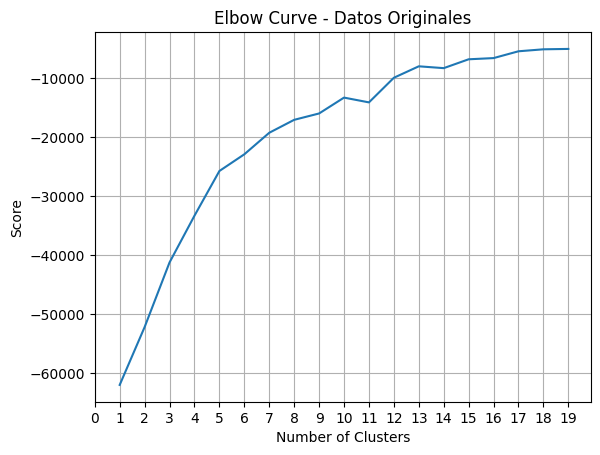

In [26]:
cluster_number = range(1, 20)
kmeans = [KMeans(n_clusters=i) for i in cluster_number]
score = [kmeans[i].fit(df_final_z).score(df_final_z) for i in range(len(kmeans))]
plt.plot(cluster_number,score)
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.xticks(np.arange(0,20,1))
plt.grid()
plt.title("Elbow Curve - Datos Originales")
plt.show()


=== K = 2 ===
Silhouette Score:        0.2394
Calinski-Harabasz Index: 12291.8940
Davies-Bouldin Index:    1.5963

=== K = 3 ===
Silhouette Score:        0.3201
Calinski-Harabasz Index: 13431.2907
Davies-Bouldin Index:    1.6679

=== K = 4 ===
Silhouette Score:        0.4055
Calinski-Harabasz Index: 16251.7920
Davies-Bouldin Index:    1.4159

=== K = 5 ===
Silhouette Score:        0.4575
Calinski-Harabasz Index: 18646.0316
Davies-Bouldin Index:    1.1218

=== K = 6 ===
Silhouette Score:        0.4974
Calinski-Harabasz Index: 19602.9327
Davies-Bouldin Index:    0.8698

=== K = 7 ===
Silhouette Score:        0.5156
Calinski-Harabasz Index: 20019.4998
Davies-Bouldin Index:    0.8469

=== K = 8 ===
Silhouette Score:        0.5347
Calinski-Harabasz Index: 20477.1430
Davies-Bouldin Index:    0.7989

=== K = 9 ===
Silhouette Score:        0.5635
Calinski-Harabasz Index: 22173.5977
Davies-Bouldin Index:    0.8064

=== K = 10 ===
Silhouette Score:        0.5915
Calinski-Harabasz Index: 22804.1

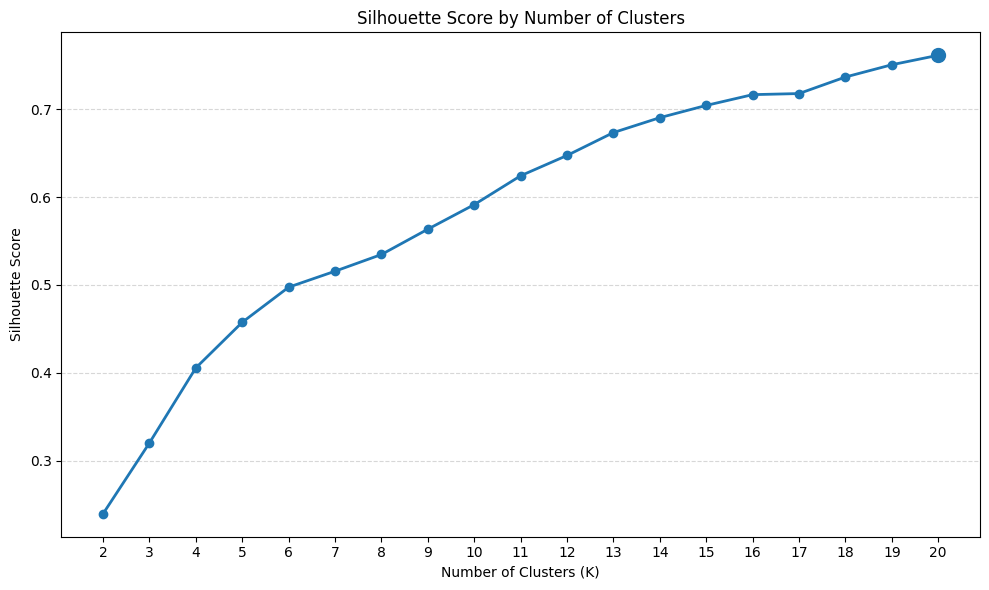

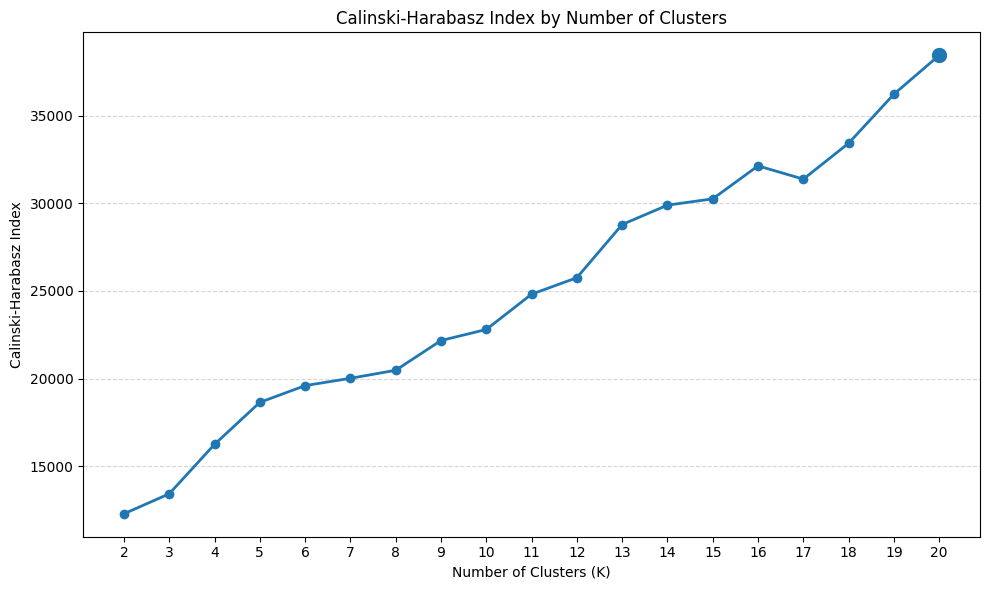

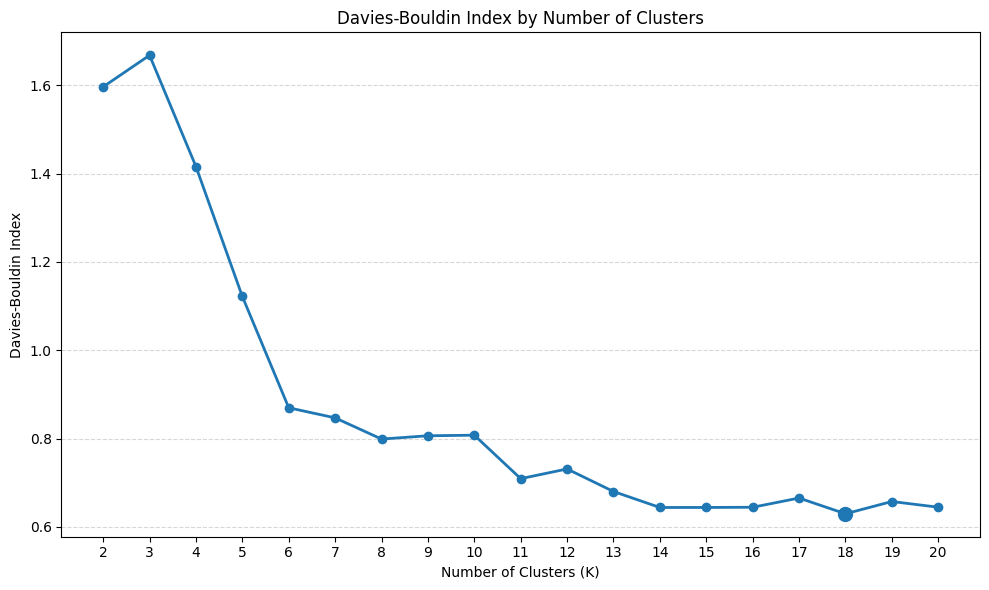

In [27]:
results = evaluate_kmeans(df_final_z, 2, 20)

### DBSCAN

In [28]:
results = evaluate_dbscan(df_final_z, 2, 20)


=== eps = 2, min_samples = 20 ===
Clusters:                1
Noise:                   0.01%
Silhouette Score:        Not available
Calinski-Harabasz Index: Not available
Davies-Bouldin Index:    Not available

No valid DBSCAN configuration was found.


### Hierarchical


=== K = 2 ===
Silhouette Score:        0.2380
Calinski-Harabasz Index: 12182.3784
Davies-Bouldin Index:    1.5332

=== K = 3 ===
Silhouette Score:        0.3380
Calinski-Harabasz Index: 14483.5542
Davies-Bouldin Index:    1.4633

=== K = 4 ===
Silhouette Score:        0.4112
Calinski-Harabasz Index: 16280.5726
Davies-Bouldin Index:    1.4400

=== K = 5 ===
Silhouette Score:        0.4582
Calinski-Harabasz Index: 17234.4926
Davies-Bouldin Index:    1.2277

=== K = 6 ===
Silhouette Score:        0.4659
Calinski-Harabasz Index: 17995.5948
Davies-Bouldin Index:    0.9739

=== K = 7 ===
Silhouette Score:        0.4869
Calinski-Harabasz Index: 17636.2381
Davies-Bouldin Index:    0.9234

=== K = 8 ===
Silhouette Score:        0.5038
Calinski-Harabasz Index: 17899.8095
Davies-Bouldin Index:    0.9154

=== K = 9 ===
Silhouette Score:        0.5431
Calinski-Harabasz Index: 18467.1519
Davies-Bouldin Index:    0.9095

=== K = 10 ===
Silhouette Score:        0.5908
Calinski-Harabasz Index: 19611.3

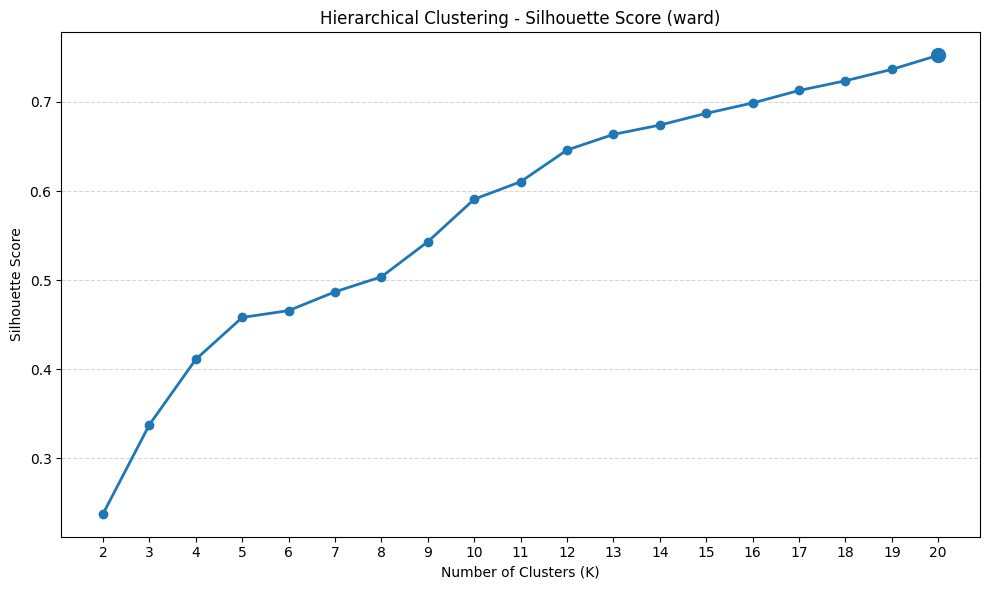

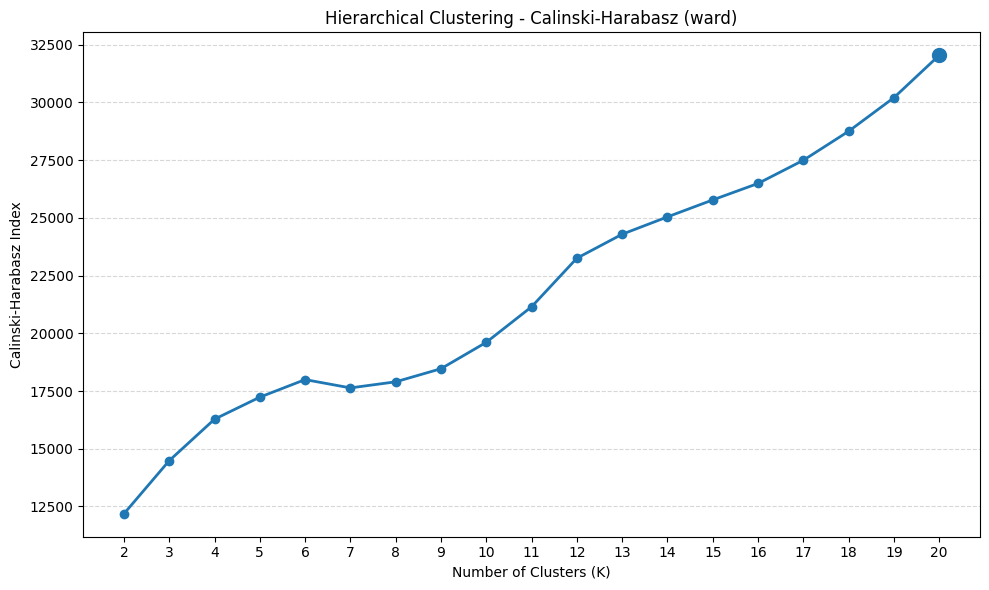

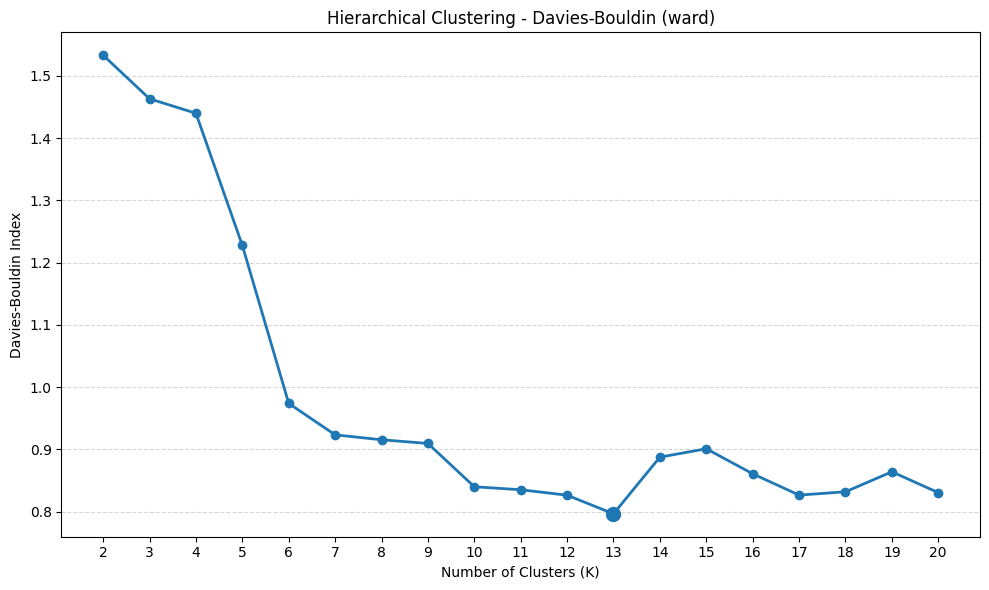

In [29]:
results_hierarchical = evaluate_hierarchical(
    df_final_z,
    k_min=2,
    k_max=20,
    linkage="ward"
)

## PCA

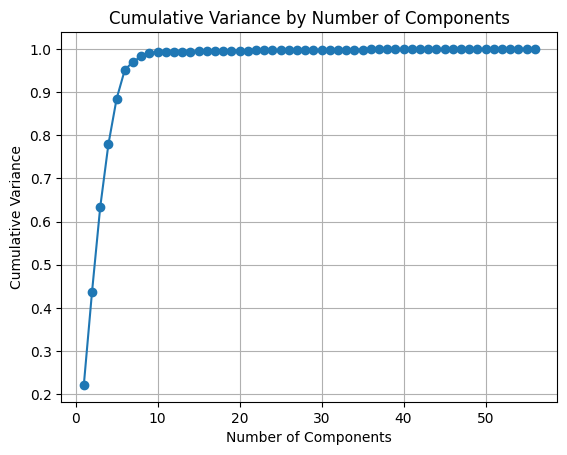

In [30]:
pca = PCA()
pca.fit(df_final_z)

var_acum = pca.explained_variance_ratio_.cumsum()

plt.plot(range(1, len(var_acum)+1), var_acum, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Variance by Number of Components')
plt.grid()
plt.show()

In [31]:
threshold = 0.99
n_comp_opt = np.argmax(var_acum >= threshold) + 1
print(f"Optimal number of components for {threshold*100:.0f}% variance: {n_comp_opt}")

Optimal number of components for 99% variance: 9


In [32]:
pca_final = PCA(n_components=9) 
df_pca = pca_final.fit_transform(df_final_z) 

# Here, we turn each of the 6 dimensions selected above into a column
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(9)]) 
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.16,-0.68,0.51,0.72,0.09,-0.13,0.03,-0.07,-0.06
1,0.68,-0.71,-0.72,-0.05,-0.35,-0.15,0.10,0.04,-0.09
2,-0.14,0.90,-0.00,0.27,-0.10,-0.02,-0.04,-0.02,0.01
3,-0.57,-0.12,-0.72,-0.22,-0.23,-0.06,-0.09,0.05,-0.00
4,0.34,0.45,-0.14,0.98,0.04,-0.16,0.06,-0.06,-0.04
...,...,...,...,...,...,...,...,...,...
50934,-0.33,0.22,-0.08,-0.33,0.91,-0.36,0.07,-0.12,-0.01
50935,0.63,0.76,0.14,-0.27,-0.35,0.03,0.07,-0.06,0.00
50936,-0.57,-0.12,-0.72,-0.22,-0.23,-0.06,-0.05,-0.11,-0.02
50937,-0.63,-0.22,0.65,0.01,-0.05,0.01,-0.05,-0.09,-0.00


#### Creation of csv

In [40]:
csv_path_towrite = script_path.parent/"data"/"mall_medellin_clustering_pca_v1.csv" 

df_pca.to_csv(csv_path_towrite,
        index=False,
        sep=";")

### K - Means

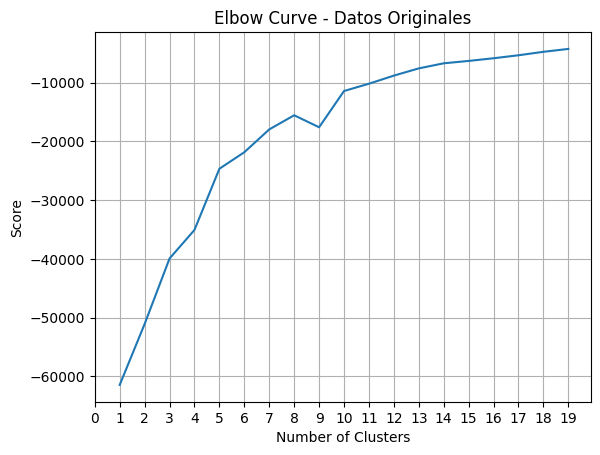

In [34]:
cluster_number = range(1, 20)
kmeans = [KMeans(n_clusters=i) for i in cluster_number]
score = [kmeans[i].fit(df_pca).score(df_pca) for i in range(len(kmeans))]
plt.plot(cluster_number,score)
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.xticks(np.arange(0,20,1))
plt.grid()
plt.title("Elbow Curve - Datos Originales")
plt.show()


=== K = 2 ===
Silhouette Score:        0.2447
Calinski-Harabasz Index: 12556.8681
Davies-Bouldin Index:    1.5259

=== K = 3 ===
Silhouette Score:        0.3307
Calinski-Harabasz Index: 14007.1870
Davies-Bouldin Index:    1.6053

=== K = 4 ===
Silhouette Score:        0.3961
Calinski-Harabasz Index: 16540.6883
Davies-Bouldin Index:    1.2850

=== K = 5 ===
Silhouette Score:        0.4652
Calinski-Harabasz Index: 19068.7672
Davies-Bouldin Index:    1.1147

=== K = 6 ===
Silhouette Score:        0.4714
Calinski-Harabasz Index: 18074.5561
Davies-Bouldin Index:    0.9254

=== K = 7 ===
Silhouette Score:        0.5264
Calinski-Harabasz Index: 20643.1590
Davies-Bouldin Index:    0.8349

=== K = 8 ===
Silhouette Score:        0.5418
Calinski-Harabasz Index: 20532.3237
Davies-Bouldin Index:    0.8531

=== K = 9 ===
Silhouette Score:        0.5891
Calinski-Harabasz Index: 22766.0642
Davies-Bouldin Index:    0.7883

=== K = 10 ===
Silhouette Score:        0.6145
Calinski-Harabasz Index: 24712.8

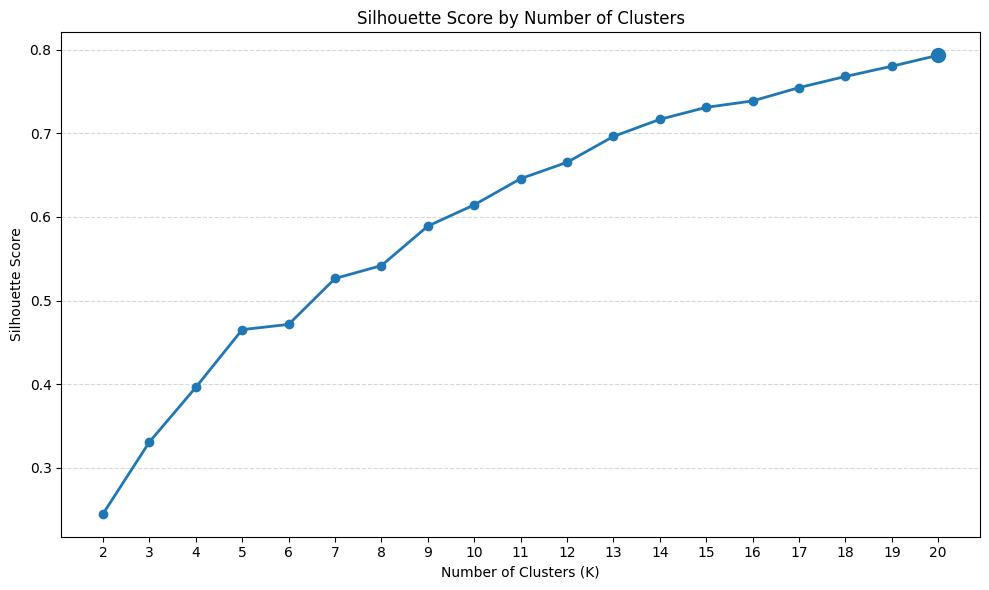

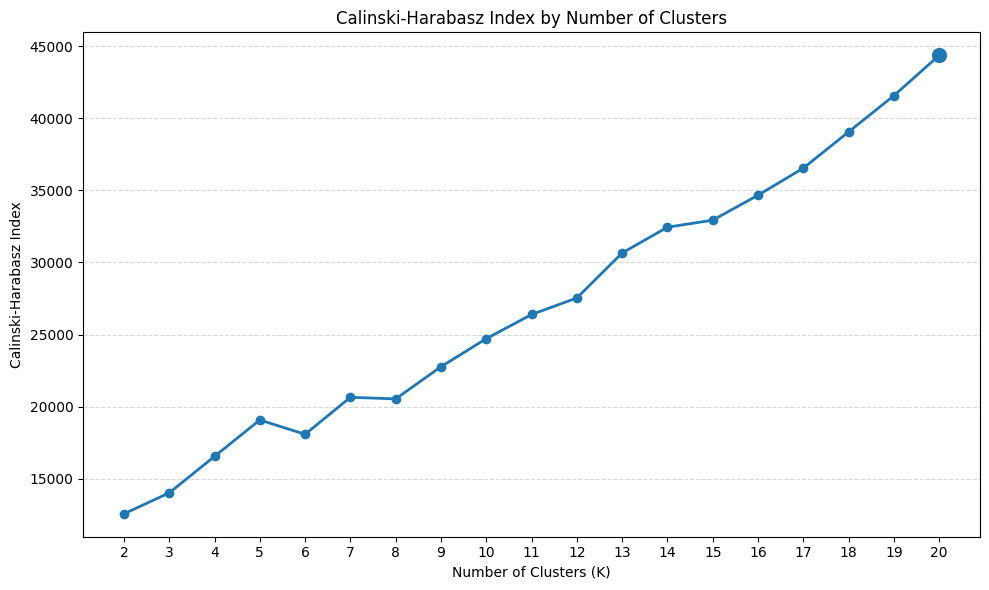

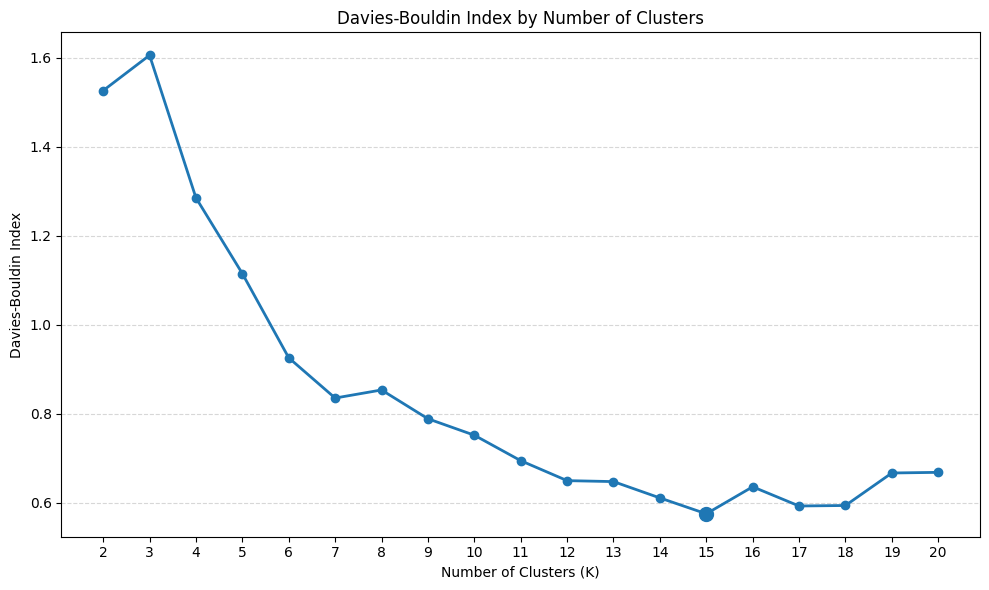

In [35]:
results = evaluate_kmeans(df_pca, 2, 20)

### DBSCAN

In [36]:
results = evaluate_dbscan(df_pca, 2, 20)


=== eps = 2, min_samples = 20 ===
Clusters:                1
Noise:                   0.00%
Silhouette Score:        Not available
Calinski-Harabasz Index: Not available
Davies-Bouldin Index:    Not available

No valid DBSCAN configuration was found.


### Hierarchical 


=== K = 2 ===
Silhouette Score:        0.2380
Calinski-Harabasz Index: 12182.3784
Davies-Bouldin Index:    1.5332

=== K = 3 ===
Silhouette Score:        0.3380
Calinski-Harabasz Index: 14483.5542
Davies-Bouldin Index:    1.4633

=== K = 4 ===
Silhouette Score:        0.4112
Calinski-Harabasz Index: 16280.5726
Davies-Bouldin Index:    1.4400

=== K = 5 ===
Silhouette Score:        0.4582
Calinski-Harabasz Index: 17234.4926
Davies-Bouldin Index:    1.2277

=== K = 6 ===
Silhouette Score:        0.4659
Calinski-Harabasz Index: 17995.5948
Davies-Bouldin Index:    0.9739

=== K = 7 ===
Silhouette Score:        0.4869
Calinski-Harabasz Index: 17636.2381
Davies-Bouldin Index:    0.9234

=== K = 8 ===
Silhouette Score:        0.5038
Calinski-Harabasz Index: 17899.8095
Davies-Bouldin Index:    0.9154

=== K = 9 ===
Silhouette Score:        0.5431
Calinski-Harabasz Index: 18467.1519
Davies-Bouldin Index:    0.9095

=== K = 10 ===
Silhouette Score:        0.5908
Calinski-Harabasz Index: 19611.3

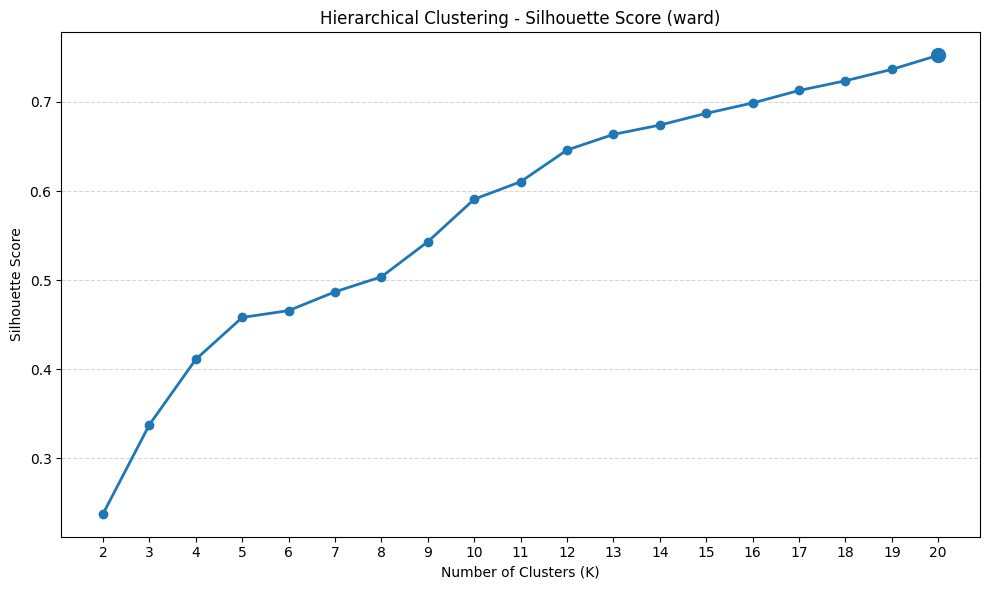

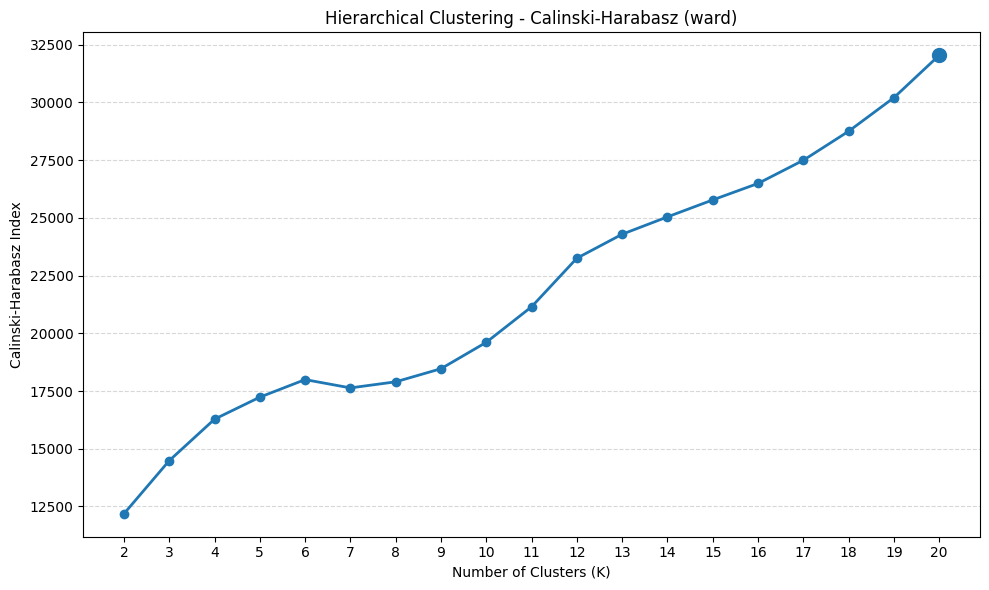

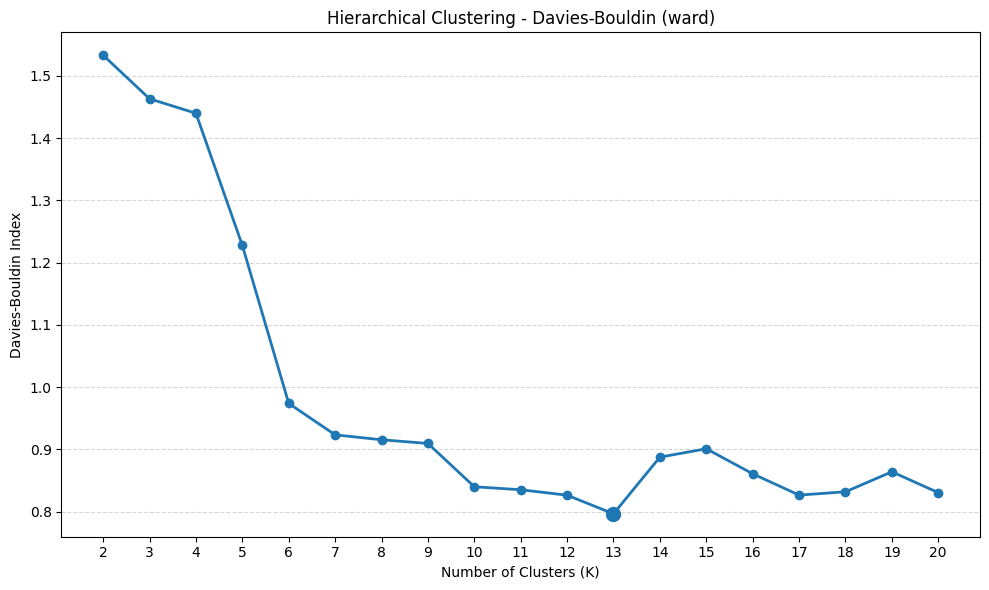

In [38]:
results_hierarchical = evaluate_hierarchical(
    df_final_z,
    k_min=2,
    k_max=20,
    linkage="ward"
)

## Best Cluster 

In [43]:
# K-Means con 12 clusters
kmeans_12 = KMeans(
    n_clusters=12,
    random_state=42,
    n_init=10
)

y_kmeans_12 = kmeans_12.fit_predict(df_pca)

In [50]:
from mpl_toolkits.mplot3d import Axes3D

In [53]:
cluster_summary = pd.DataFrame({
    "Cluster": y_kmeans_12
})

cluster_summary = (
    cluster_summary["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_summary.columns = ["Cluster", "Number of People"]

cluster_summary["Percentage"] = (
    cluster_summary["Number of People"]
    / cluster_summary["Number of People"].sum()
    * 100
)

print("=== Cluster Distribution ===")
print(cluster_summary.to_string(index=False))

=== Cluster Distribution ===
 Cluster  Number of People  Percentage
       0              6290       12.35
       1              5869       11.52
       2              2938        5.77
       3              8142       15.98
       4              6993       13.73
       5              3234        6.35
       6              3098        6.08
       7              3119        6.12
       8              3574        7.02
       9              3710        7.28
      10              2092        4.11
      11              1880        3.69


In [59]:
df_cluster_profile = df_final_z.copy()

df_cluster_profile["Cluster"] = y_kmeans_12

cluster_means = (
    df_cluster_profile
    .groupby("Cluster")
    .mean()
)

In [62]:
vmin=0,
vmax=1

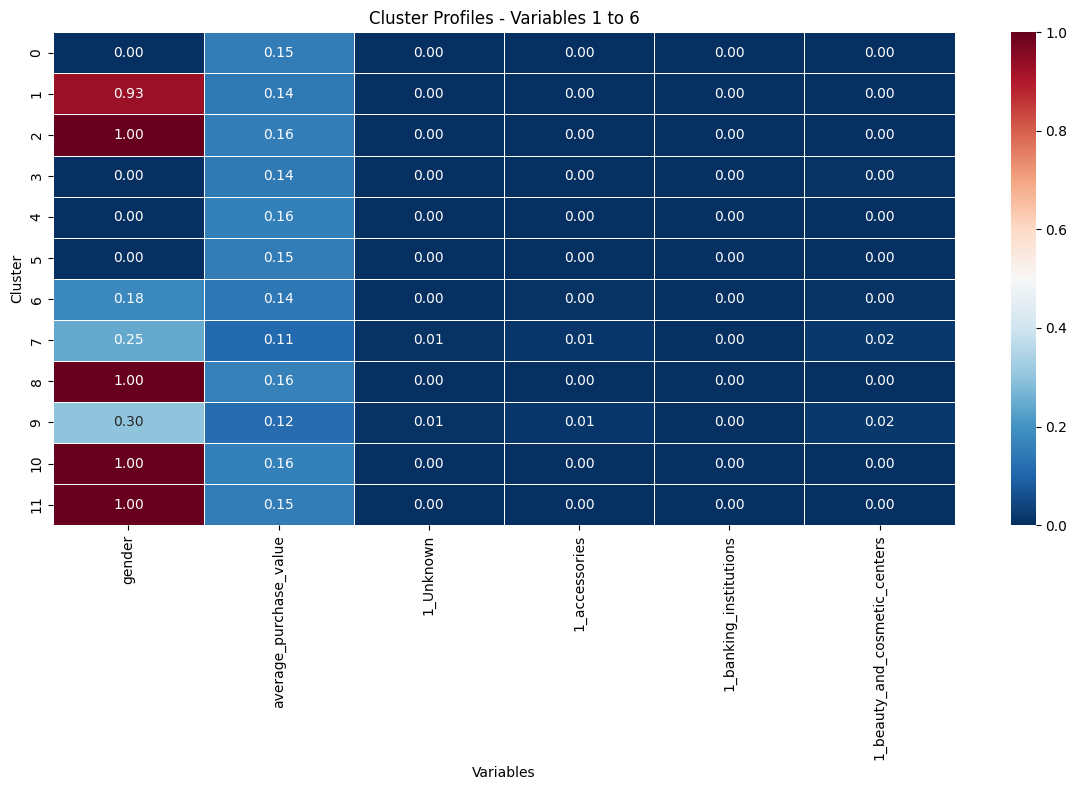

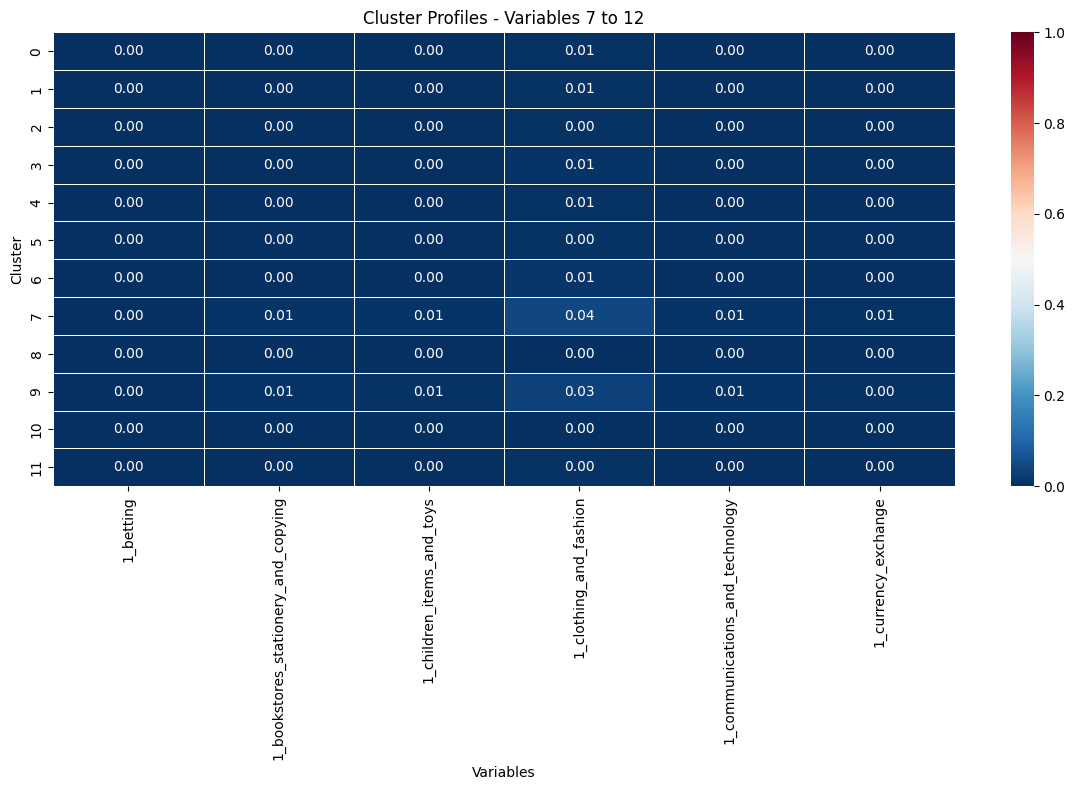

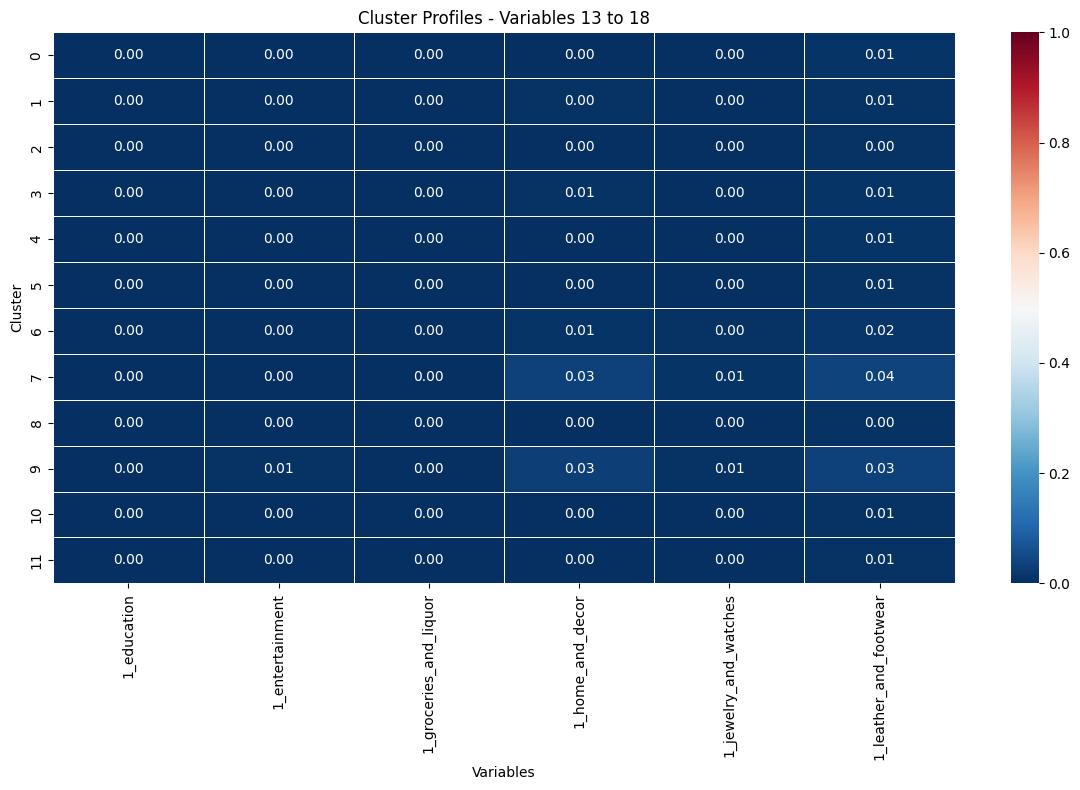

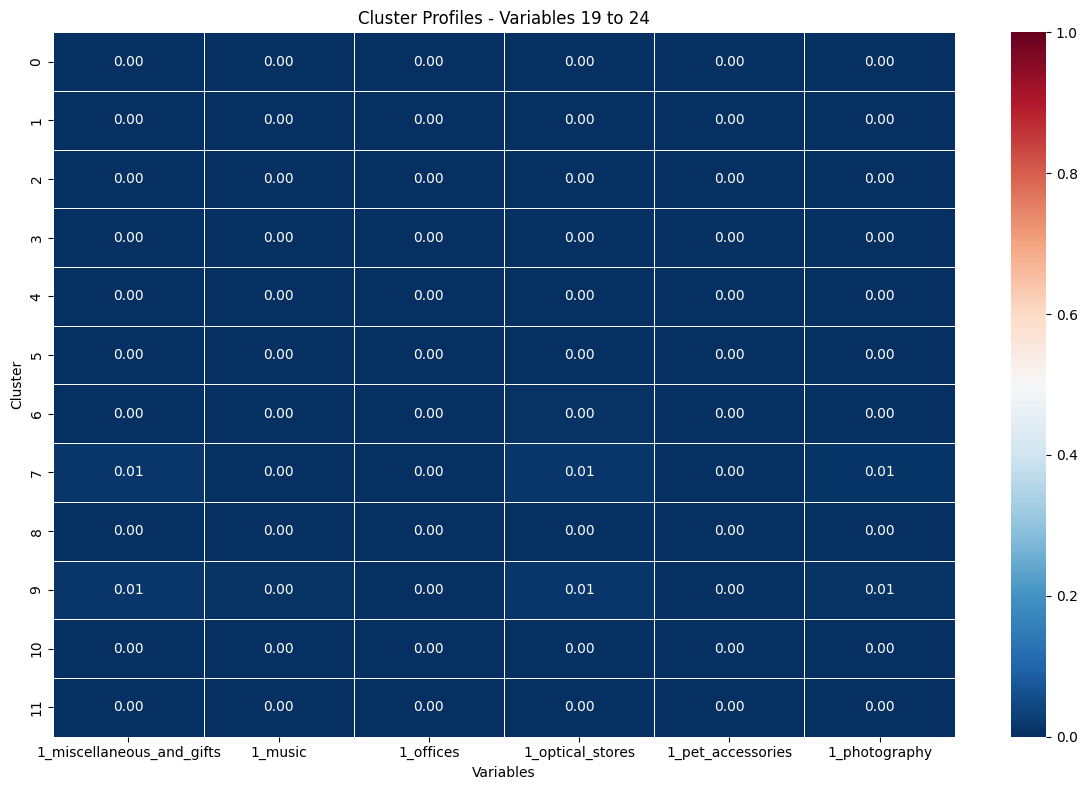

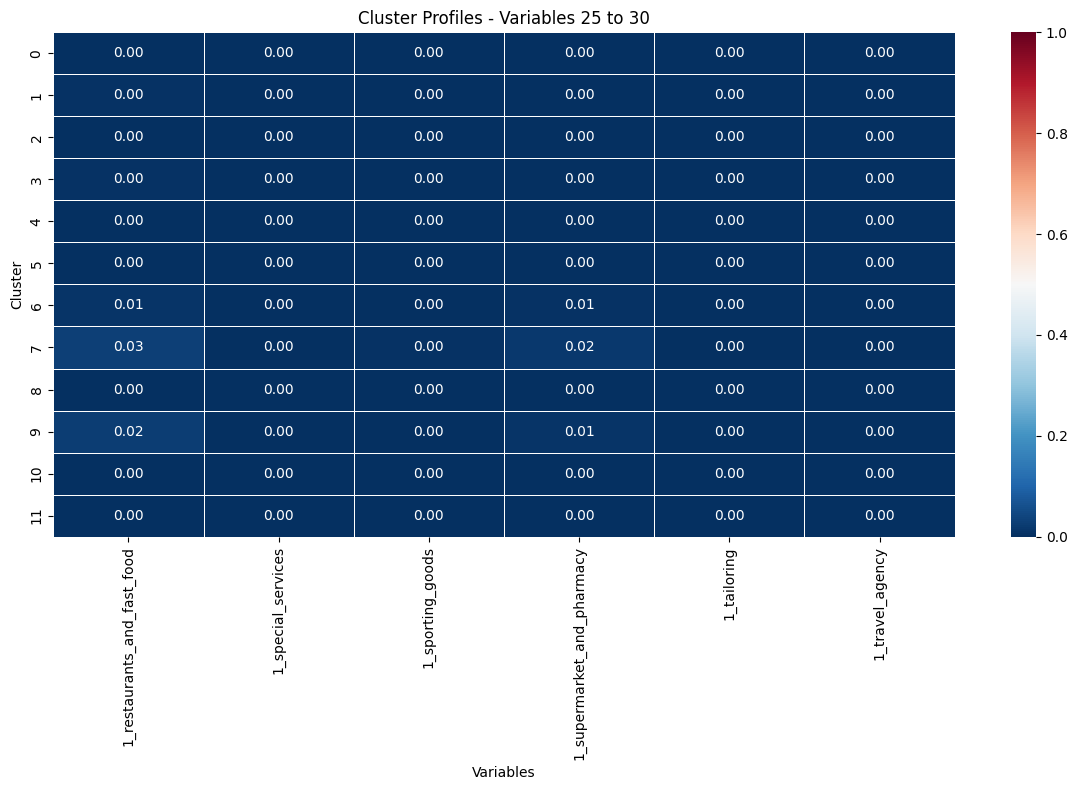

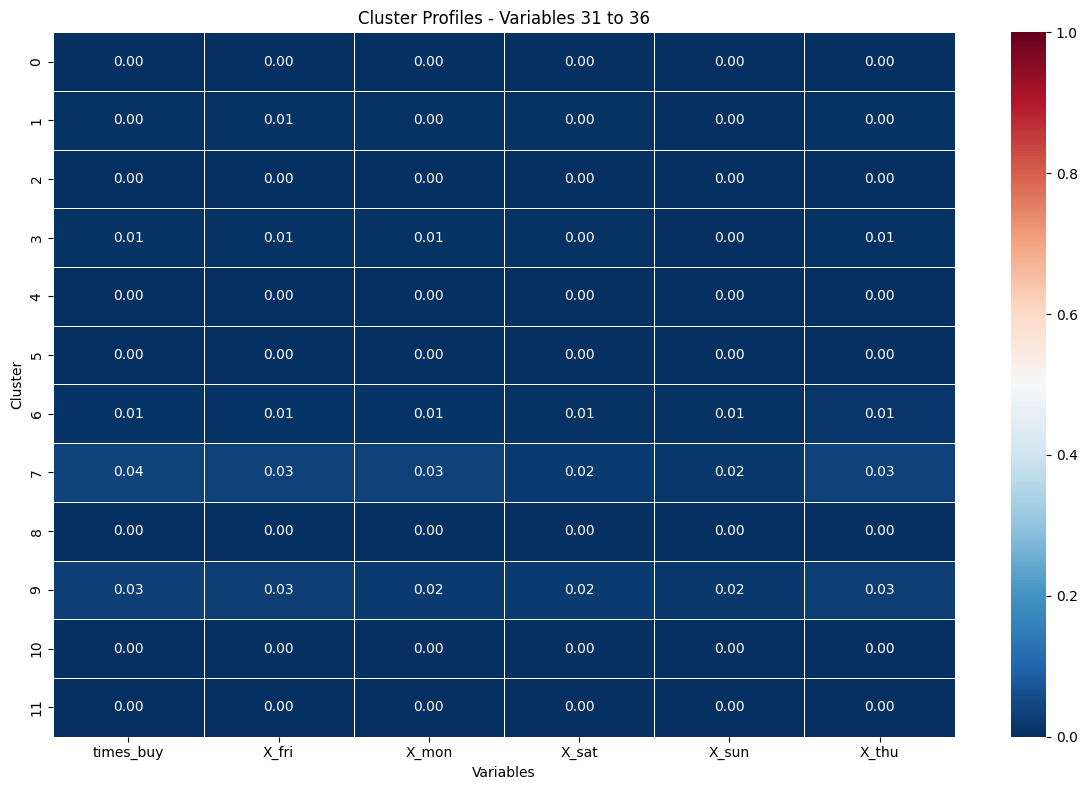

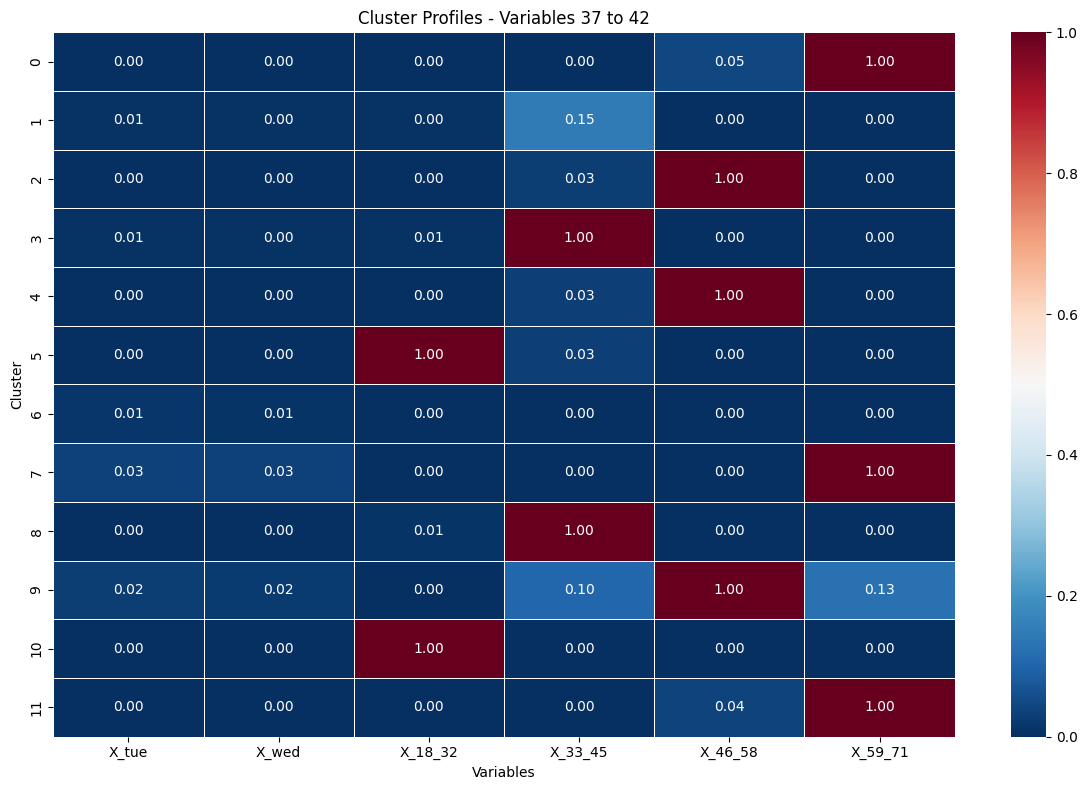

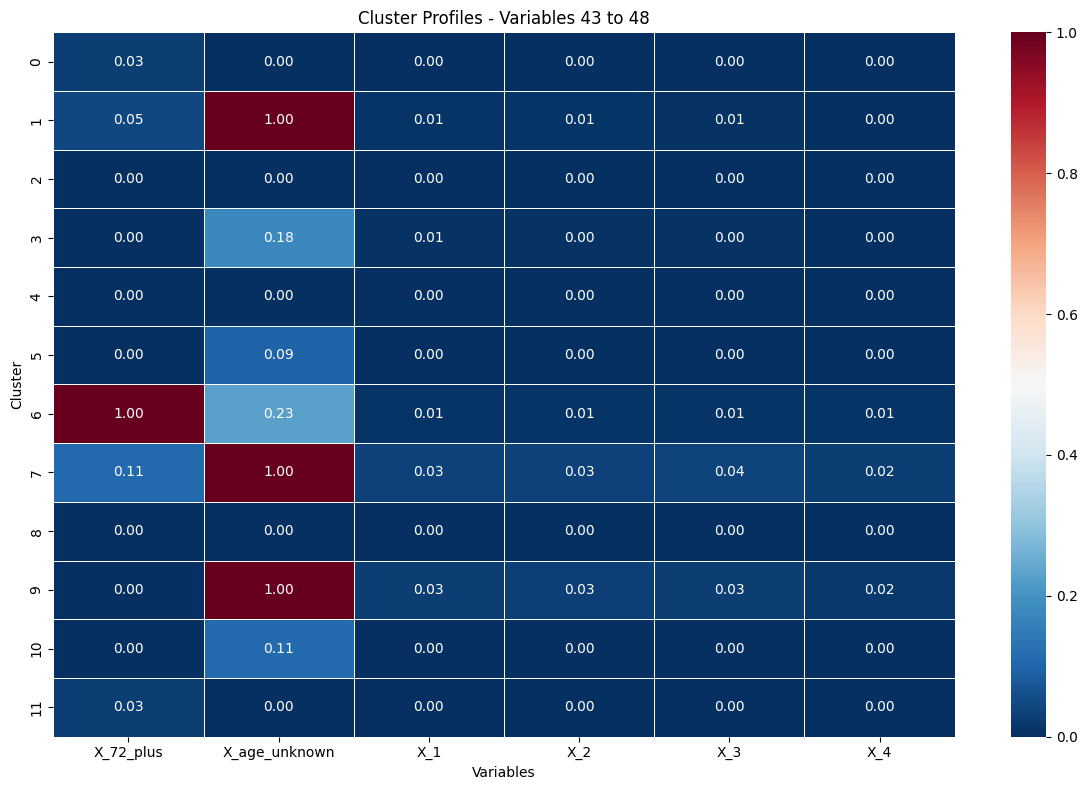

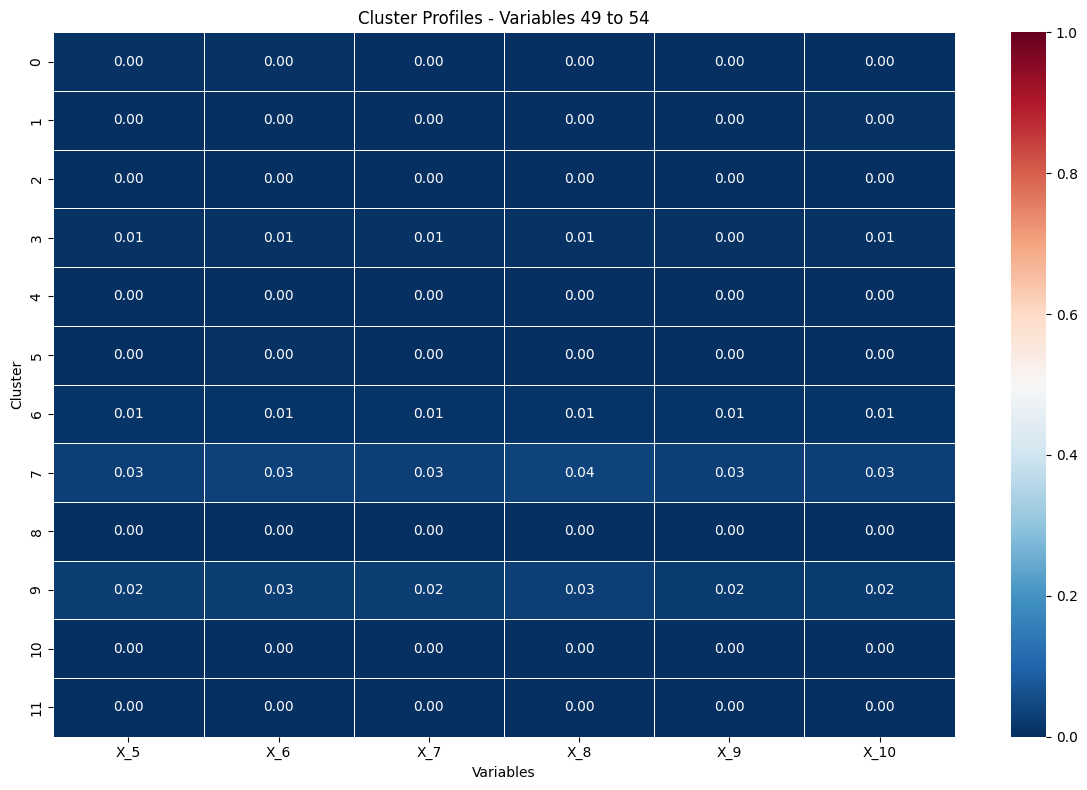

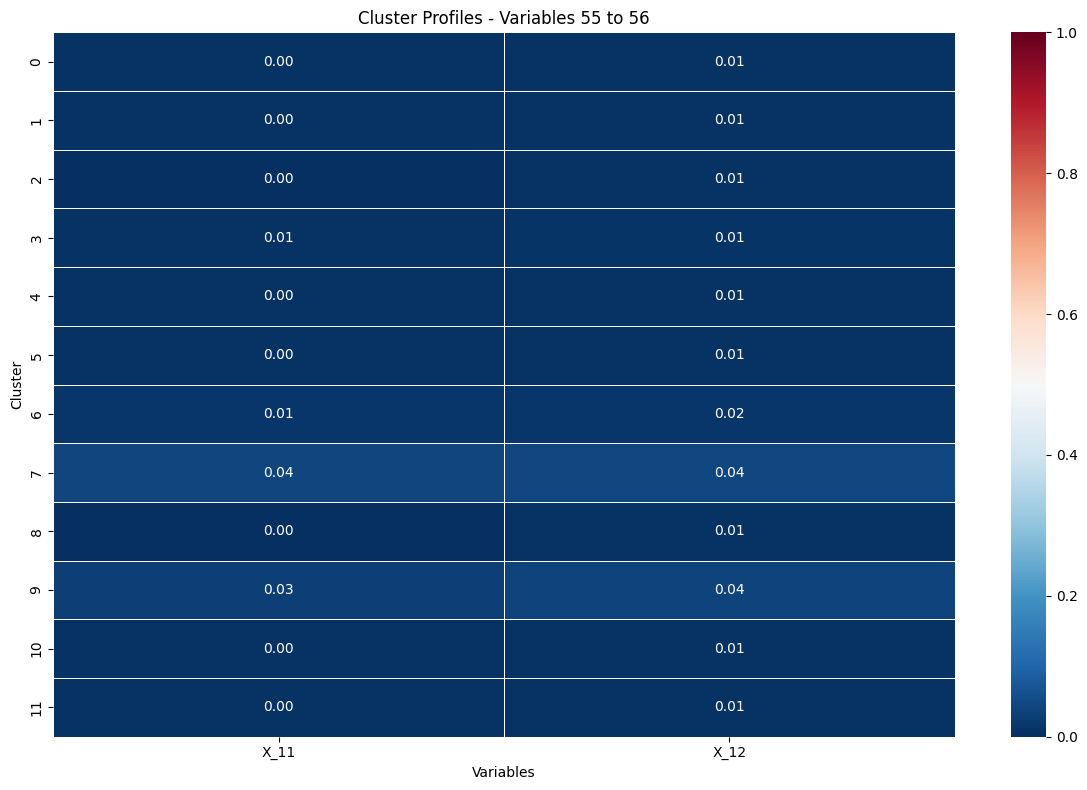

In [63]:
variables_per_plot = 6

variables = cluster_means.columns

for i in range(0, len(variables), variables_per_plot):

    variables_group = variables[i:i + variables_per_plot]

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        cluster_means[variables_group],
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=0,
        vmax=1,
        linewidths=0.5
    )

    plt.title(
        f"Cluster Profiles - Variables {i + 1} to "
        f"{min(i + variables_per_plot, len(variables))}"
    )

    plt.xlabel("Variables")
    plt.ylabel("Cluster")

    plt.tight_layout()
    plt.show()

# Version

In [41]:
# ============================================================
# Library versions
# ============================================================

import sklearn

print("=== Library Versions ===")
print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"seaborn:      {sns.__version__}")
print(f"matplotlib:   {plt.matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

=== Library Versions ===
pandas:       2.3.2
numpy:        2.3.4
seaborn:      0.13.2
matplotlib:   3.10.6
scikit-learn: 1.7.2
